In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

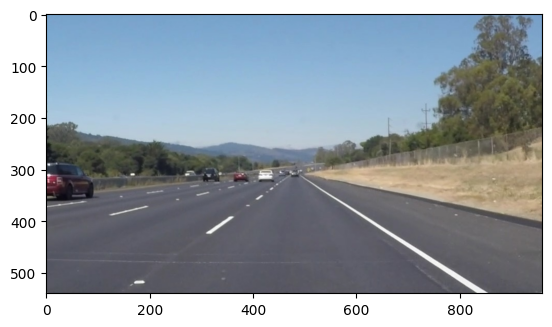

In [39]:
img = cv2.imread('data/images/test_img1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

Text(0.5, 1.0, 'Threshold Image')

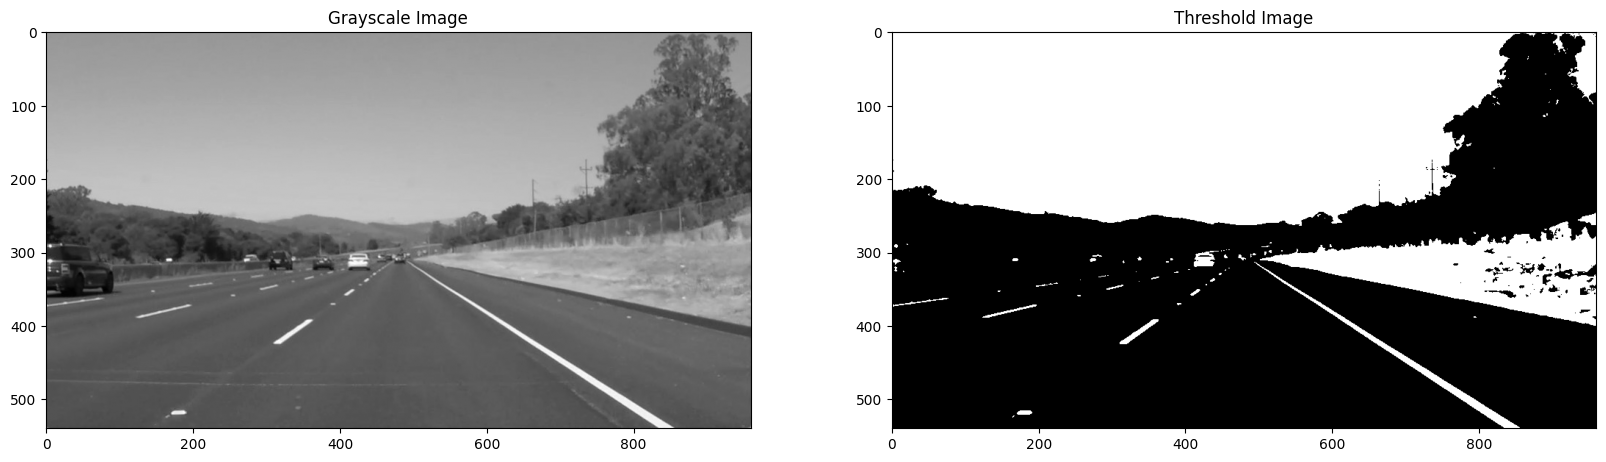

In [40]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

threshold = cv2.inRange(img_gray, 150, 255)

plt.figure(figsize=(20, 10))
plt.subplot(121);plt.imshow(img_gray, cmap='gray');plt.title('Grayscale Image')
plt.subplot(122);plt.imshow(threshold, cmap='gray');plt.title('Threshold Image')

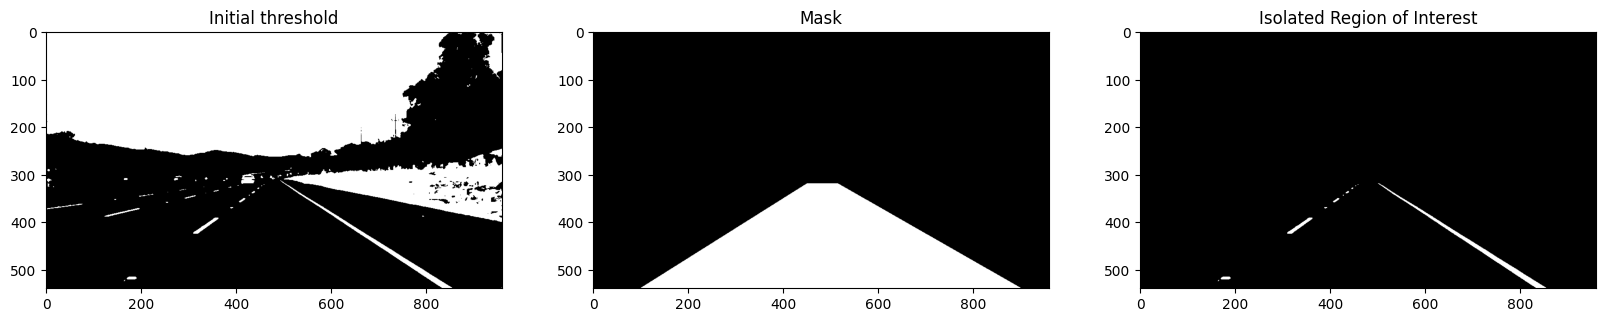

In [41]:
roi_vertices = np.array([[[100, 540], 
                         [900, 540],
                         [515, 320],
                         [450, 320]]])

mask = np.zeros_like(threshold)

if len(threshold.shape) > 2:
    channel_count = threshold.shape[2]
    ignore_mask_color = (255,) * channel_count
else:
    ignore_mask_color = 255

cv2.fillPoly(mask, roi_vertices, ignore_mask_color)

roi = cv2.bitwise_and(threshold, mask)

plt.figure(figsize=(20, 10))
plt.subplot(131);plt.imshow(threshold, cmap='gray');plt.title('Initial threshold');
plt.subplot(132);plt.imshow(mask, cmap='gray');plt.title('Mask');
plt.subplot(133);plt.imshow(roi, cmap='gray');plt.title('Isolated Region of Interest');

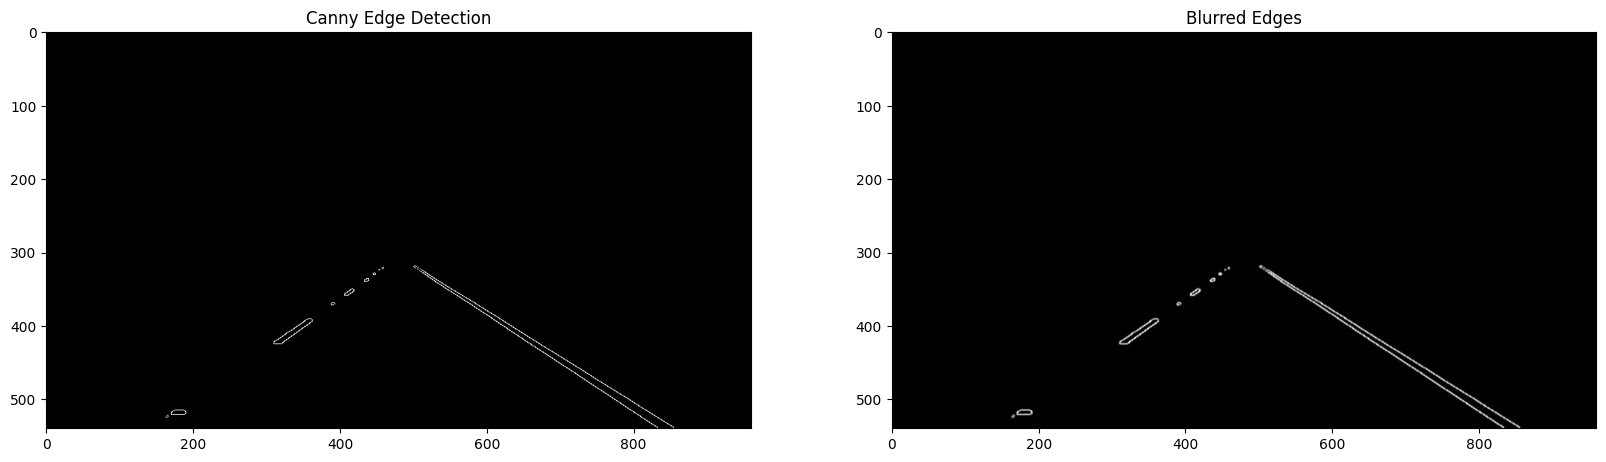

In [42]:
low_threshold = 50
high_threshold = 100
edges = cv2.Canny(roi, low_threshold, high_threshold)

kernel_size = 3
canny_blur = cv2.GaussianBlur(edges, (kernel_size, kernel_size), 0)

plt.figure(figsize=(20, 10))
plt.subplot(121);plt.imshow(edges, cmap = 'gray');plt.title('Canny Edge Detection');
plt.subplot(122);plt.imshow(canny_blur, cmap='gray');plt.title('Blurred Edges');

In [43]:
def draw_lines(img, lines, color = [255, 0, 0], thickness = 2):
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                cv2.line(img, (x1, y1), (x2, y2), color, thickness)

Found 21 lines, including: [[500 318 853 539]]


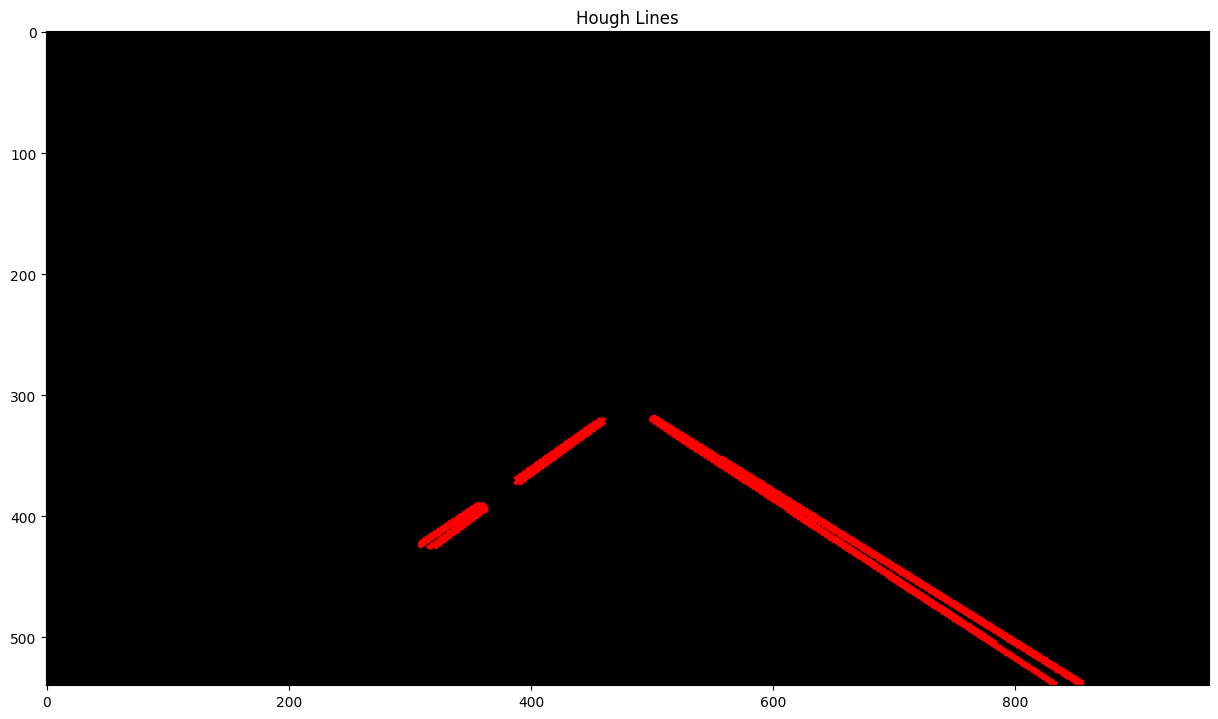

In [44]:
rho = 1
theta = np.pi / 180
threshold = 50
min_line_length = 10
max_line_gap = 20

lines = cv2.HoughLinesP(canny_blur, rho, theta, threshold, minLineLength = min_line_length, maxLineGap = max_line_gap)

hough = np.zeros((img.shape[0], img.shape[1], 3), dtype = np.uint8)
draw_lines(hough, lines)

print('Found {} lines, including: {}'.format(len(lines), lines[0]))
plt.figure(figsize = (15, 10)); plt.imshow(hough);plt.title('Hough Lines');

In [45]:
def separate_left_right_lines(lines):
    left_lines = []
    right_lines = []
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                if y1 > y2:
                    left_lines.append([x1, y1, x2, y2])
                elif y1 < y2:
                    right_lines.append([x1, y1, x2, y2])

    return left_lines, right_lines

In [46]:
def cal_avg(values):
    if (type(values) != 'NoneType'):
        if len(values) > 0:
            n = len(values)
        else:
            n = 1

        return sum(values) / n

In [47]:
def extrapolate_lines(lines, upper_border, lower_border):
    slopes = []
    consts = []

    if lines is not None:
        for x1, y1,x2, y2 in lines:
            slope = (y1 - y2)/ (x1 - x2)
            slopes.append(slope)
            c = y1 - slope * x1
            consts.append(c)

    avg_slope = cal_avg(slopes)
    avg_consts = cal_avg(consts)

    x_lane_lower_point = int((lower_border - avg_consts) / avg_slope)

    x_lane_upper_point = int((upper_border - avg_consts) / avg_slope)

    return [x_lane_lower_point, lower_border, x_lane_upper_point, upper_border]

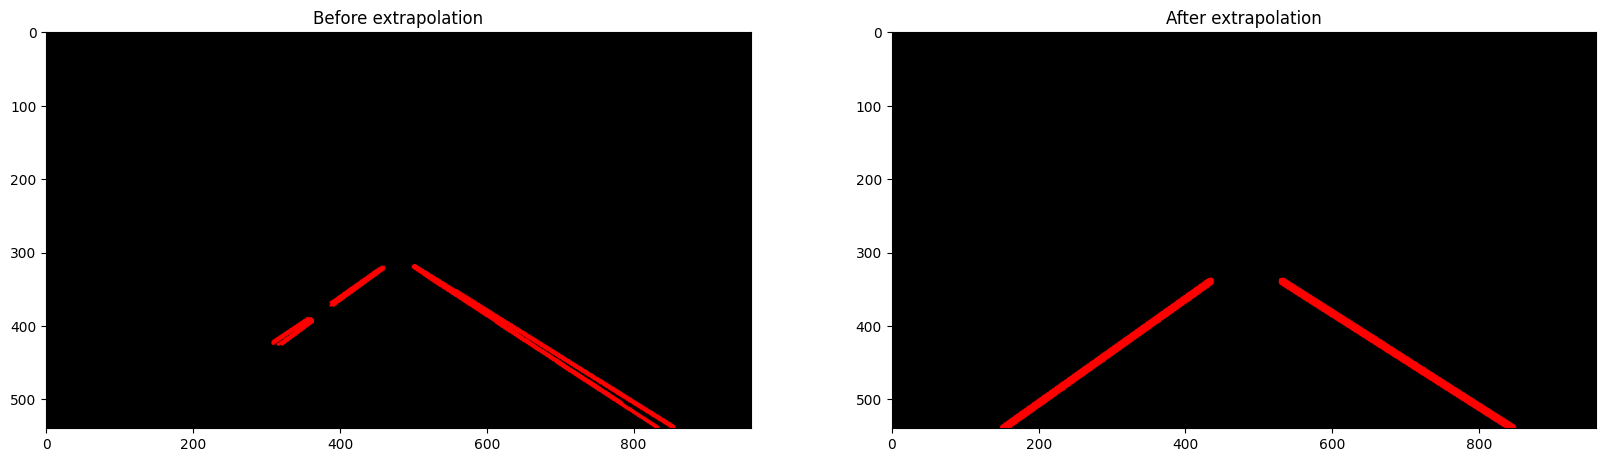

In [48]:
# Define bounds of the region of interest.
roi_upper_border = 340
roi_lower_border = 540

# Create a blank array to contain the (colorized) results.
lanes_img = np.zeros((img.shape[0], img.shape[1], 3), dtype = np.uint8)

# Use above defined function to identify lists of left-sided and right-sided lines.
lines_left, lines_right = separate_left_right_lines(lines)

# Use above defined function to extrapolate the lists of lines into recognized lanes.
lane_left = extrapolate_lines(lines_left, roi_upper_border, roi_lower_border)
lane_right = extrapolate_lines(lines_right, roi_upper_border, roi_lower_border)
draw_lines(lanes_img, [[lane_left]], thickness = 10)
draw_lines(lanes_img, [[lane_right]], thickness = 10)

# Display results.
fig = plt.figure(figsize = (20, 20))
ax = fig.add_subplot(1, 2, 1); plt.imshow(hough); ax.set_title('Before extrapolation')
ax = fig.add_subplot(1, 2, 2); plt.imshow(lanes_img); ax.set_title('After extrapolation');
plt.show()

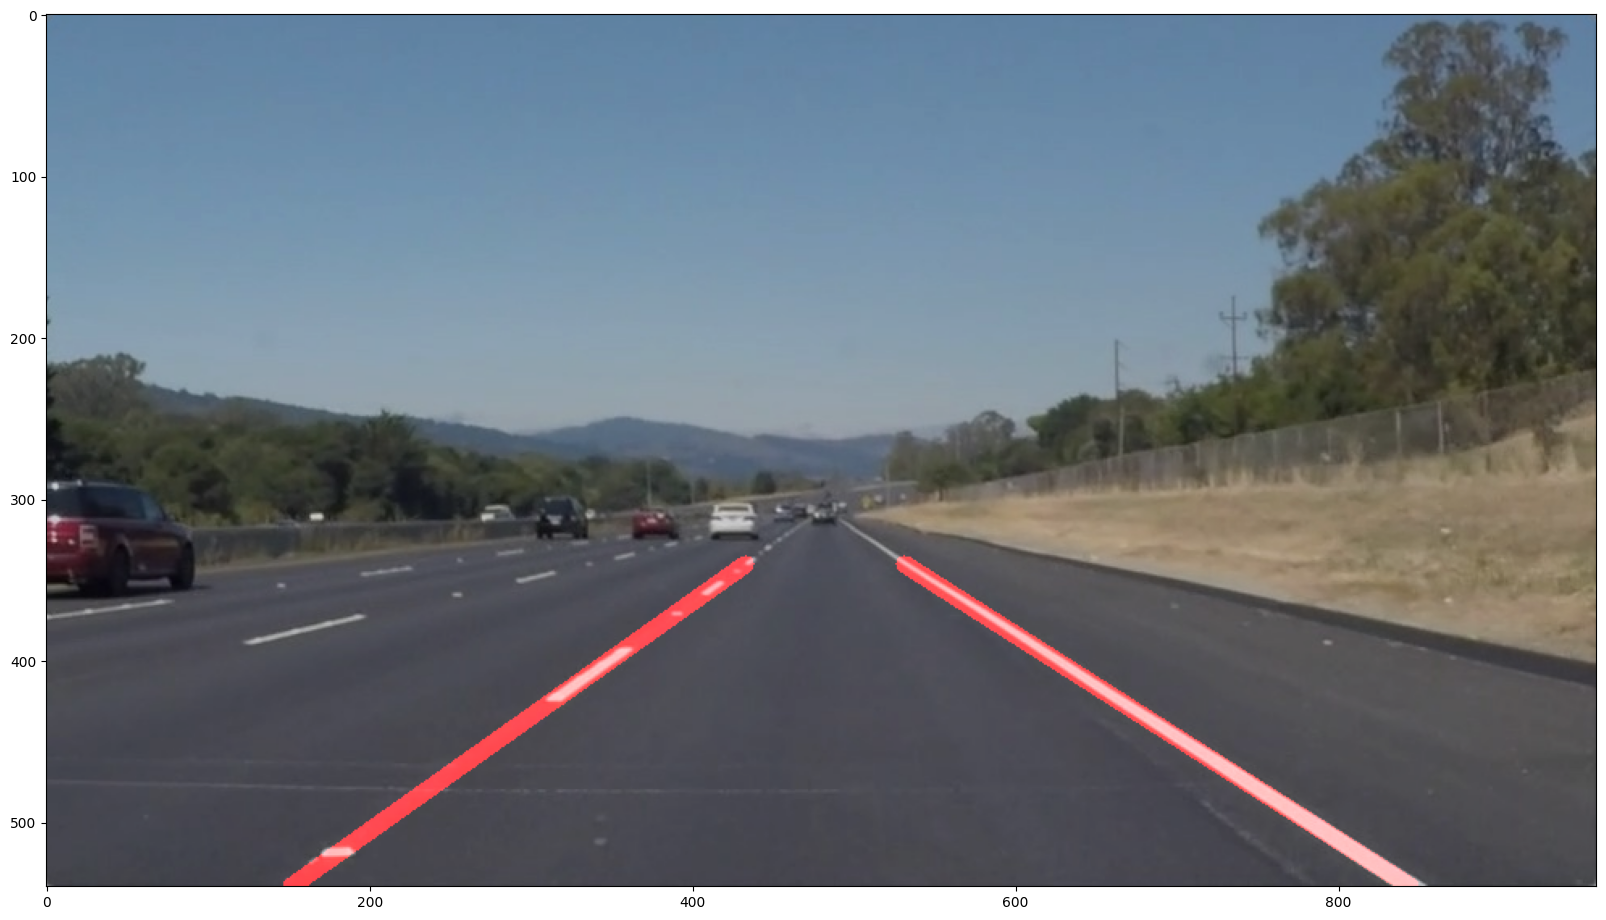

In [49]:
alpha = 0.8
beta = 1.0
gamma = 0.0
image_annotated = cv2.addWeighted(img, alpha, lanes_img, beta, gamma)

# Display the results, and save image to file.
fig = plt.figure(figsize = (20, 20))
plt.imshow(image_annotated)
image_annotated = cv2.cvtColor(image_annotated, cv2.COLOR_BGR2RGB)
cv2.imwrite('data/images/Lane1-image.jpg', image_annotated);

#### Application: Lane Detection in Video

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
def region_of_interest(img, vertices):
    """Select the region of interest (ROI) from a defined list of vertices."""
    # Defines a blank mask.
    mask = np.zeros_like(img)   
    
    # Defining a 3 channel or 1 channel color to fill the mask.
    if len(img.shape) > 2:
        channel_count = img.shape[2]  # 3 or 4 depending on your image.
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255
        
    # Filling pixels inside the polygon.
    cv2.fillPoly(mask, vertices, ignore_mask_color)
    
    # Returning the image only where mask pixels are nonzero.
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image


def draw_lines(img, lines, color=[255, 0, 0], thickness = 2):
    """Utility for drawing lines."""
    if lines is not None:
        for line in lines:
            for x1,y1,x2,y2 in line:
                cv2.line(img, (x1, y1), (x2, y2), color, thickness)


def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """Utility for defining Line Segments."""
    lines = cv2.HoughLinesP(
        img, rho, theta, threshold, np.array([]),
        minLineLength = min_line_len, maxLineGap = max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype = np.uint8)
    draw_lines(line_img, lines)
    return line_img, lines


def separate_left_right_lines(lines):
    """Separate left and right lines depending on the slope."""
    left_lines = []
    right_lines = []
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                if y1 > y2: # Negative slope = left lane.
                    left_lines.append([x1, y1, x2, y2])
                elif y1 < y2: # Positive slope = right lane.
                    right_lines.append([x1, y1, x2, y2])
    return left_lines, right_lines


def cal_avg(values):
    """Calculate average value."""
    if not (type(values) == 'NoneType'):
        if len(values) > 0:
            n = len(values)
        else:
            n = 1
        return sum(values) / n


def extrapolate_lines(lines, upper_border, lower_border):
    """Extrapolate lines keeping in mind the lower and upper border intersections."""
    slopes = []
    consts = []
    
    if (lines is not None) and (len(lines) != 0):
        for x1, y1, x2, y2 in lines:
            slope = (y1-y2) / (x1-x2)
            slopes.append(slope)
            c = y1 - slope * x1
            consts.append(c)
        avg_slope = cal_avg(slopes)
        avg_consts = cal_avg(consts)

        # Calculate average intersection at lower_border.
        x_lane_lower_point = int((lower_border - avg_consts) / avg_slope)

        # Calculate average intersection at upper_border.
        x_lane_upper_point = int((upper_border - avg_consts) / avg_slope)

        return [x_lane_lower_point, lower_border, x_lane_upper_point, upper_border]


def draw_con(img, lines):
    """Fill in lane area."""
    points = []
    for x1,y1,x2,y2 in lines[0]:
        points.append([x1,y1])
        points.append([x2,y2])
    for x1,y1,x2,y2 in lines[1]:
        points.append([x2,y2])
        points.append([x1,y1])

    points = np.array([points], dtype = 'int32')        
    cv2.fillPoly(img, points, (0,255,0))
    

def extrapolated_lane_image(img, lines, roi_upper_border, roi_lower_border):
    """Main function called to get the final lane lines."""
    lanes_img = np.zeros((img.shape[0], img.shape[1], 3), dtype = np.uint8)
    # Extract each lane.
    lines_left, lines_right = separate_left_right_lines(lines)
    lane_left = extrapolate_lines(lines_left, roi_upper_border, roi_lower_border)
    lane_right = extrapolate_lines(lines_right, roi_upper_border, roi_lower_border)
    if lane_left is not None and lane_right is not None:
        draw_con(lanes_img, [[lane_left], [lane_right]])
    return lanes_img

In [7]:
def process_image(image):  
    # Convert to grayscale.
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Intensity selection.
    gray_select = cv2.inRange(gray, 150, 255)
    
    # Region masking: Select vertices according to the input image.
    roi_vertices = np.array([[[100, 540], [900, 540], [525, 330], [440, 330]]])
    gray_select_roi = region_of_interest(gray_select, roi_vertices)
    
    # Canny Edge Detection.
    low_threshold = 50
    high_threshold = 100
    img_canny = cv2.Canny(gray_select_roi, low_threshold, high_threshold)
    
    # Remove noise using Gaussian blur.
    kernel_size = 5
    canny_blur = cv2.GaussianBlur(img_canny, (kernel_size, kernel_size), 0)
    
    # Hough transform parameters set according to the input image.
    rho = 1
    theta = np.pi/180
    threshold = 100
    min_line_len = 50
    max_line_gap = 300
    hough, lines = hough_lines(canny_blur, rho, theta, threshold, min_line_len, max_line_gap)
    
    # Extrapolate lanes.
    roi_upper_border = 330
    roi_lower_border = 540
    lane_img = extrapolated_lane_image(image, lines, roi_upper_border, roi_lower_border)
    
    # Combined using weighted image.
    image_result = cv2.addWeighted(image, 1, lane_img, 0.4, 0.0)
    return image_result

In [8]:
video_cap = cv2.VideoCapture('data/videos/lane1-straight.mp4')
if not video_cap.isOpened(): 
  print("Error opening video stream or file")

In [ ]:
frame_w   = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h   = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_fps = int(video_cap.get(cv2.CAP_PROP_FPS))

# Select fourcc encoding for the mp4 file.
# Having issues? You could also try: *'mp4v' or *'avc1'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# Specify the video output filenames.
file_out = 'data/videos/lane1-straight-output.mp4'

# Create the video writer objects.
vid_out = cv2.VideoWriter(file_out, fourcc, frame_fps, (frame_w,frame_h))

In [10]:
print("Begin processing video... Wait until 'finished' message!")
while True:
    ret, frame = video_cap.read()
    if frame is None:
        print("Finished processing video")
        break
    result = process_image(frame)
    vid_out.write(result)

# Close the video writer stream.
vid_out.release()

Begin processing video... Wait until 'finished' message!
Finished processing video
